<a href="https://colab.research.google.com/github/Kommmi/Qaos/blob/main/04_Quantum_Complexity_Environment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!rm -rf Qaos
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Qaos.git

# Move into the repo
%cd Qaos

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

print("Module ready to go :)")



Module ready to go :)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from gqs.states import Initial_state
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.PlotsDynamics import plot_two_gqs_trajectory_row
from gqs.Gamma import Compare_distances_All, Gamma_calculator
from gqs.SSCI import SSCI_calculator

# L-qubit Quantum Kicked Top

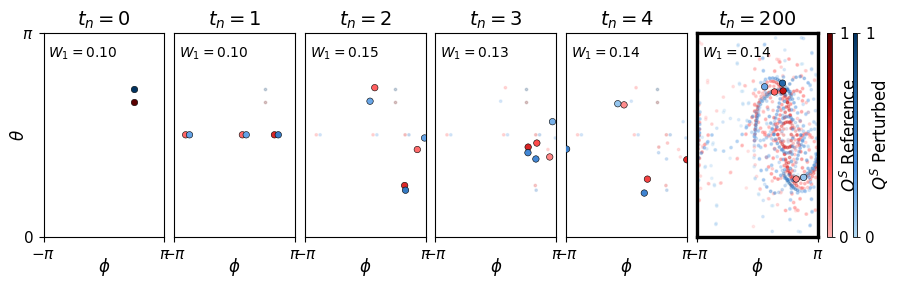

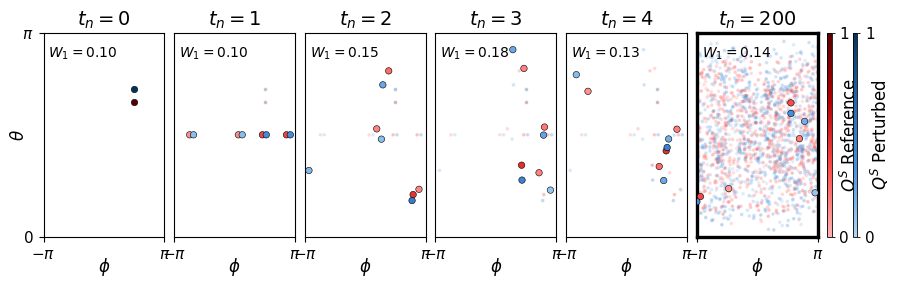

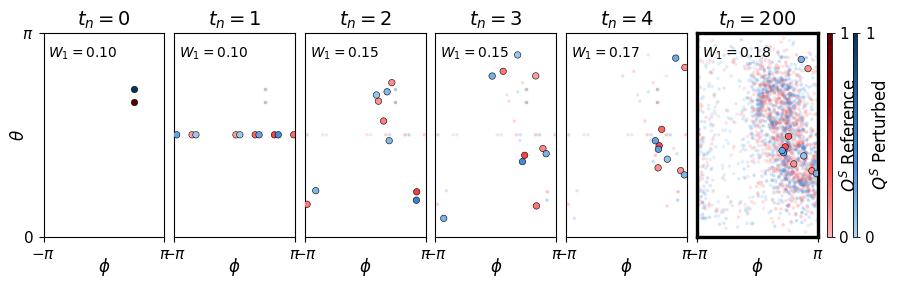

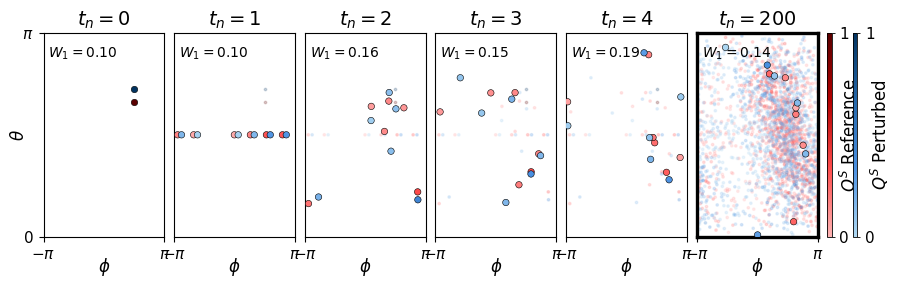

In [3]:
nqubitArr = [3,4,5,6]
kappa = 2.5                                     # <--- kappa- interaction strength, nqubits - number of qubits in kicked top
# Two neighboring Global States - taken to be a spin coherent state but can be changed to a more general Psi
theta, phi, eps = np.pi/2+0.5, np.pi/2, 0.2

for nqubit in nqubitArr:
  #Dynamics of the reduced states
  H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
  U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
  psi_reference = Initial_state(nqubit,theta,phi)
  psi_perturbed = Initial_state(nqubit, theta+eps, phi)
  _= plot_two_gqs_trajectory_row(U_F=U_F, psi_reference=psi_reference, psi_perturbed=psi_perturbed, selected_kicks=(0,1,2,3,4,200))




# Quantifying complexity with changing environment size - Sensitivity

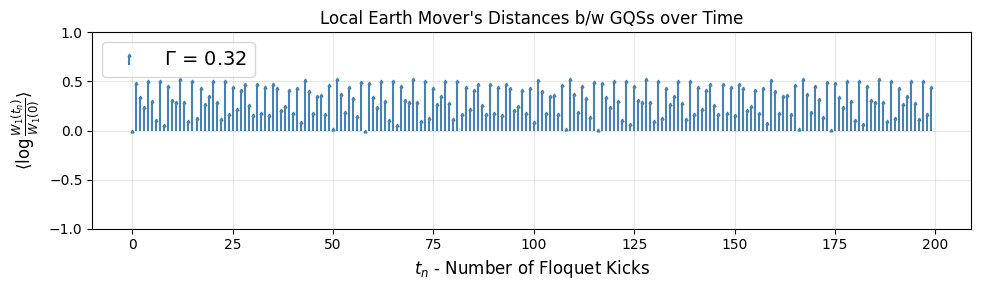

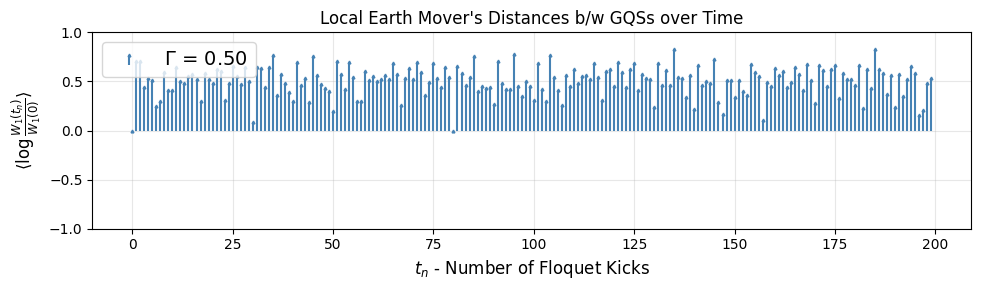

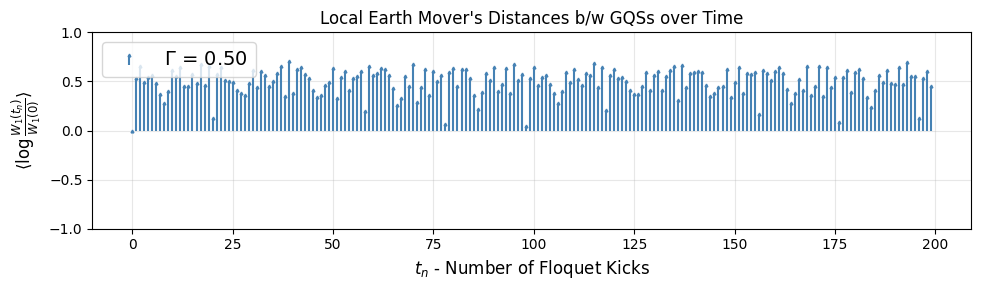

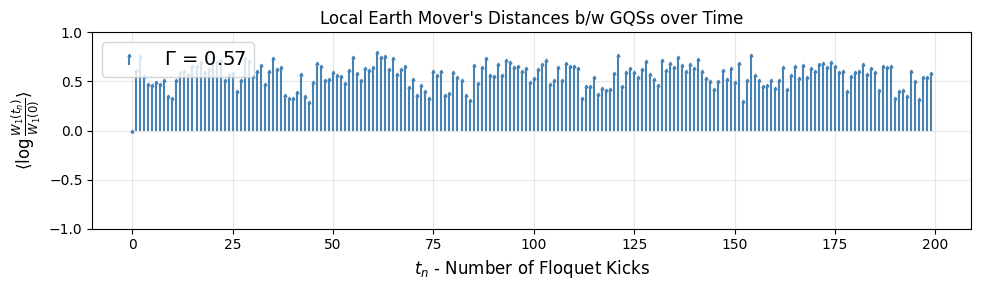

In [12]:
for nqubit in nqubitArr:
    #Dynamics of the reduced states
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
    _=Gamma_calculator(U_F,nqubit=nqubit,theta0=theta,phi0=phi,eps=eps,N_traj=10,N_kicks=200,show_plot=True)

# Quantifying complexity with changing environment size - Spread

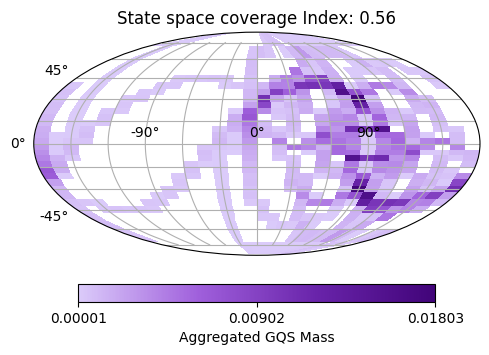

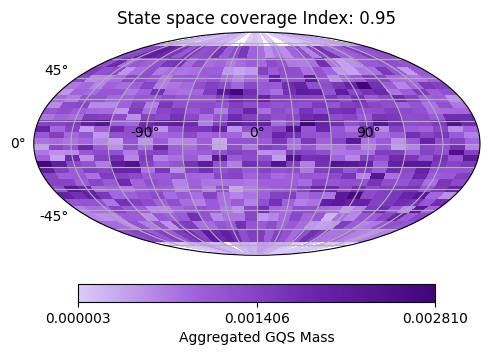

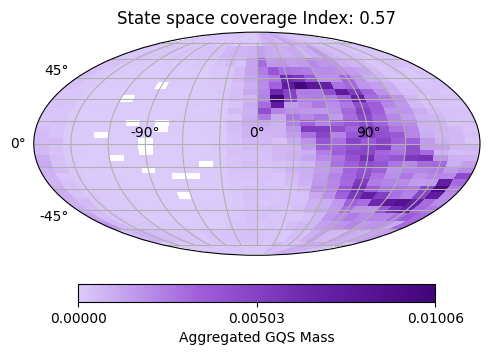

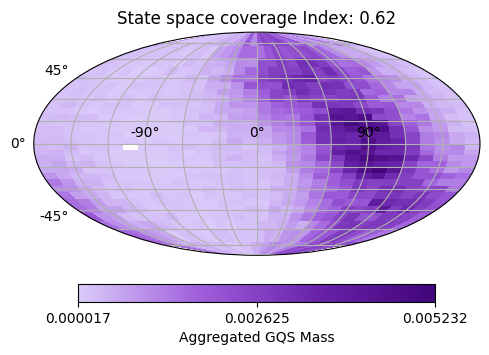

In [13]:
for nqubit in nqubitArr:
    #Dynamics of the reduced states
    H1, H2 = Hamiltonian_QK(tau=1.0,kappa=kappa,nqubit=nqubit) # <--- Quantum Kicked Top Hamiltonian,
    U_F = floquet_operator_from_H(H1,H2,tau=1.0,)              # <--- Floquet operator from QKT Hamiltonian
    _=SSCI_calculator(kappa=kappa,nqubit=nqubit,nkicks=5000,theta=theta,phi=phi,show_plot=True,)